Transient Richards equation on heterogeneous material. <br>
$\left(c(\psi)\frac{\partial}{\partial t} \psi - \nabla\cdot(k_sk_r(\psi)\nabla(z+\psi))\right) = 0$
with $\psi<0$ in unsaturated conditions and <br>
$c(\psi) = \alpha m (\phi - \theta_r) N S_e(\psi)^{\frac{1}{m}}\left(1-S_e(\psi)^{\frac{1}{m}}\right)^m$ for $m = 1-1/N$.

In [1]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    assemble_matrix,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem,
    create_matrix, 
    create_vector, 
)
from dolfinx.io import XDMFFile
from dolfinx.mesh import (
    create_unit_square,
    locate_entities,
    meshtags,
    compute_midpoints,
    CellType,
)
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
import ufl
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    sqrt,
    ln,
    lhs,
    rhs,
    conditional,
    derivative,
)

from petsc4py import PETSc
import numpy as np
import pyvista

from visualization_fct import *

## Set up mesh and FE spaces

In [2]:
def create_quad_domain(comm, nx, ny, p0, p1, p2, p3, celltype=CellType.triangle):
    """
    Create a domain defined by four corner points.

    Args:
        comm (mpi4py.MPI.Intracomm): MPI communicator
        nx (int): number of cells in x-direction
        ny (int): number of cells in y-direction
        p0 (np.array): x and y coordinates of the bottom-left corner point
        p1 (np.array): x and y coordinates of the bottom-right corner point
        p2 (np.array): x and y coordinates of the top-right corner point
        p3 (np.array): x and y coordinates of the top-left corner point

    Returns:
        dolfinx.mesh: Domain defined by the corner points.
    """

    mesh = create_unit_square(comm, nx, ny, cell_type=celltype)

    x = mesh.geometry.x
    xi = x[:, 0]
    eta = x[:, 1]

    x[:, :2] = (
        np.outer((1-xi)*(1-eta), p0) +
        np.outer(xi*(1-eta), p1) +
        np.outer(xi*eta, p2) +
        np.outer((1-xi)*eta, p3)
    )
    return mesh

In [3]:
# -------------------------------------------------
# Mesh
# -------------------------------------------------
# Generate domain from four corner points
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 10, 10, P0, P1, P2, P3)

# Interface
slope = (P1[1]-P0[1])/(P1[0]-P0[0]) # slope of bottom and top boundary

tdim = domain.topology.dim

# -------------------------------------------------
# FE spaces
# -------------------------------------------------

V = fem.functionspace(domain, ("CG", 1))   # pressure head
Q = fem.functionspace(domain, ("DG", 0))   # material parameters
v = TestFunction(V)
x = SpatialCoordinate(domain)


## Set up heterogeneous material

In [4]:

# -------------------------------------------------
# DG0 parameter fields
# -------------------------------------------------

Ks      = fem.Function(Q)
alpha   = fem.Function(Q)
n_vg    = fem.Function(Q)
theta_r = fem.Function(Q)
theta_s = fem.Function(Q)

# -------------------------------------------------
# Material assignment
# -------------------------------------------------

# Define parameters for each layer (layer 1: loam, layer 2: sand) (from bottom to top)
layer_params = {
    1: {"name": "loam", "alpha": 3.6, "N": 1.56, "theta_r": 0.078, "theta_s": 0.43, "Ks": 2.89e-6, "locator": lambda x: False},
    2: {"name": "sand", "alpha": 14.5, "N": 2.68, "theta_r": 0.045, "theta_s": 0.43, "Ks": 8.25e-5, "locator": lambda x: x[1] >= slope*x[0] + P3[1]/2 - 1e-14},
    3: {"name": "silt", "alpha": 1.6, "N": 1.37, "theta_r": 0.034, "theta_s": 0.46, "Ks": 6.94e-7, "locator": lambda x: x[1] < slope*x[0] + P3[1]/2 - 1e-14},
}

num_cells = domain.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)

midpoints = mesh.compute_midpoints(domain, tdim, cells)

Ks_vals      = np.zeros(num_cells)
alpha_vals   = np.zeros(num_cells)
n_vals       = np.zeros(num_cells)
theta_r_vals = np.zeros(num_cells)
theta_s_vals = np.zeros(num_cells)

for c, x in enumerate(midpoints):
    # Check in which layer the midpoint is and assign the corresponding parameters
    for key, value in layer_params.items():
        if value["locator"](x):
            Ks_vals[c] = value["Ks"]
            alpha_vals[c] = value["alpha"]
            n_vals[c] = value["N"]
            theta_r_vals[c] = value["theta_r"]
            theta_s_vals[c] = value["theta_s"]

# -------------------------------------------------
# Store into DG0 functions
# -------------------------------------------------

Ks.x.array[:] = Ks_vals
alpha.x.array[:] = alpha_vals
n_vg.x.array[:] = n_vals
theta_r.x.array[:] = theta_r_vals
theta_s.x.array[:] = theta_s_vals

Ks.x.scatter_forward()
alpha.x.scatter_forward()
n_vg.x.scatter_forward()
theta_r.x.scatter_forward()
theta_s.x.scatter_forward()


In [5]:
# -------------------------------------------------
# Define parametrizations
# -------------------------------------------------

from ufl import max_value, min_value


def theta(u, alpha, N, theta_r, theta_s):
    t = conditional(u <= 0, theta_r + (theta_s - theta_r)*(1 + (-alpha*u)**N)**(1/N-1), theta_s)
    return t

def Se(u, alpha, N, theta_r, theta_s):
    return (theta(u, alpha, N, theta_r, theta_s) - theta_r)/(theta_s - theta_r)

def k(u, alpha, N, theta_r, theta_s, Ks):
    m = 1 - 1/N
    kr = conditional(u <= 0, Se(u, alpha, N, theta_r, theta_s)**0.5*(1 - (1 - Se(u, alpha, N, theta_r, theta_s)**(1/m))**m)**2, 1)
    return Ks*kr

def C(u, alpha, N, theta_r, theta_s):
    m = 1 - 1/N
    Sm = Se(u, alpha, N, theta_r, theta_s)**(1/m)
    Cval = conditional(Sm < 1, alpha * m * (theta_s - theta_r) * N * Sm * (1 - Sm)**m, 0)
    return Cval

""" def S_e(u, alpha, N):
    eps = 1e-8
    #a1 = conditional(u < -eps, 1 + exp(ln(alpha * (-u))*N), 1)
    #exp1 = (1 - N) / N
    #S = exp(ln(a1)*exp1)

    eps = 1e-12

    m = 1 - 1/N

    Se = conditional(
        u < -eps,
        (1 + (alpha * (-u))**N)**(-m),
        1.0
    )
    return Se

def k(u, alpha, N, Ks):
    S = S_e(u, alpha, N)
    m = N / (N-1)
    a1 = 1 - exp(ln(S)*m)
    a2 = 1 - exp(ln(a1) / m)
    kr = sqrt(S) * a2 ** 2
    return kr*Ks

def C(u, alpha, N, theta_r, theta_s):
    m = 1 - 1/N

    Se = S_e(u, alpha, N)

    Cval = conditional(
        u < 0,
        (theta_s - theta_r)*(1-N)*(alpha*(-u))**N*(1+(alpha*(-u))**N)**(-m - 1)/u,
        0
        )
    return Cval

def theta(u, alpha, N):
    return conditional(u < 0, theta_r + (theta_s - theta_r)*S_e(u, alpha, N), theta_s) """

' def S_e(u, alpha, N):\n    eps = 1e-8\n    #a1 = conditional(u < -eps, 1 + exp(ln(alpha * (-u))*N), 1)\n    #exp1 = (1 - N) / N\n    #S = exp(ln(a1)*exp1)\n\n    eps = 1e-12\n\n    m = 1 - 1/N\n\n    Se = conditional(\n        u < -eps,\n        (1 + (alpha * (-u))**N)**(-m),\n        1.0\n    )\n    return Se\n\ndef k(u, alpha, N, Ks):\n    S = S_e(u, alpha, N)\n    m = N / (N-1)\n    a1 = 1 - exp(ln(S)*m)\n    a2 = 1 - exp(ln(a1) / m)\n    kr = sqrt(S) * a2 ** 2\n    return kr*Ks\n\ndef C(u, alpha, N, theta_r, theta_s):\n    m = 1 - 1/N\n\n    Se = S_e(u, alpha, N)\n\n    Cval = conditional(\n        u < 0,\n        (theta_s - theta_r)*(1-N)*(alpha*(-u))**N*(1+(alpha*(-u))**N)**(-m - 1)/u,\n        0\n        )\n    return Cval\n\ndef theta(u, alpha, N):\n    return conditional(u < 0, theta_r + (theta_s - theta_r)*S_e(u, alpha, N), theta_s) '

## Boundary conditions

In [6]:
# Boundary conditions

# Define the gw table at the right boundary to be below 0.
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
def gamma_out(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] >= 0)
def gamma_in(x):
    return np.isclose(x[1], slope*x[0]+P3[1])
def bottom(x):
    return np.isclose(x[1], slope*x[0])
def gamma_bed(x):
    return np.logical_or(bottom(x), np.isclose(x[0], 0))

boundaries = [
    (1, gamma_bed),
    (2, on_dirichlet),
    (3, gamma_out),
    (4, gamma_in)
]

# We now loop through all the boundary conditions and create MeshTags identifying the facets for each boundary condition.
facet_indices, facet_markers = [], []
fdim = domain.topology.dim - 1
for marker, locator in boundaries:
    facets = locate_entities(domain, fdim, locator) # find boundary facet
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32) # make array of arrays into single array
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(
    domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]
) # each boundary facet gets identified with its boundary condition

domain.topology.create_connectivity(fdim, domain.topology.dim) # connect facets to cells

# Create custom integration measure
ds = Measure("ds", domain, subdomain_data=facet_tag)

# Create general boundary condition class
class BoundaryCondition:
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            facets = facet_tag.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(PETSc.ScalarType(values), dofs, V)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))

    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [7]:
# Define boundary conditions
c_in = 2e-9 # recharge
boundary_conditions = [
    BoundaryCondition("Neumann", 1, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Dirichlet", 2, 0),
    BoundaryCondition("Neumann", 3, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Neumann", 4, Constant(domain, default_scalar_type(c_in)))
]

bcs = []
for condition in boundary_conditions:
    if condition.type == "Dirichlet":
        bcs.append(condition.bc)

## Start solving

In [8]:
# Set up time parametrization
t = 0.0 # start time
delta_t = 30 # time step size [s]
max_iter_time = 3600 # maximum number of iterations
tol_time = 1e-6 # max difference between u_n+1 and u_n until we assume steady state

#### Picard:

In [9]:
facets = facet_tag.find(2)
dofs_Dirichlet = locate_dofs_topological(V, fdim, facets)

In [10]:
v = TestFunction(V)
u_n = Function(V)
u_n.x.array[:] = -1e-6*np.ones_like(u_n.x.array) # previous (time step) solution

max_iter = 20 # maximum number of Picard iterations
tol = 1e-6

delta_u = 1
it = 1

while delta_u > tol_time and it <= max_iter_time:
    it += 1
    u_m = Function(V)
    u_m.x.array[:] = u_n.x.array # First guess for Picard: previous time step
    du = TrialFunction(V)
    
    # Build variational formulation
    conductivity = k(u_m, alpha, n_vg, theta_r, theta_s, Ks)
    theta_n = theta(u_n, alpha, n_vg, theta_r, theta_s)
    theta_m = theta(u_m, alpha, n_vg, theta_r, theta_s)

    C_part = 1/delta_t * C(u_m, alpha, n_vg, theta_r, theta_s) * du * v * dx
    var_part = dot(conductivity * grad(du), grad(v)) * dx
    rest = dot(conductivity * grad(u_m + x[1]), grad(v)) * dx + (theta_m - theta_n) / delta_t  * v * dx - v*c_in*ds(4)
    F = C_part + var_part + rest

    a_fem = lhs(F)
    L_fem = rhs(F)

    #du = Function(V)
    u_mp1 = Function(V)

    # Prepare Picard iteration
    m = 0 # iteration count
    eps = 1

    while eps > tol and m < max_iter:
        # Calculate boundary conditions for du: du@bd = u_D - u_m@bd
        du_Dirichlet = Function(V)
        du_Dirichlet.x.array[:] = 0 - u_m.x.array
        bc_du = dirichletbc(du_Dirichlet, dofs_Dirichlet)

        problem = LinearProblem(
            a_fem, L_fem, bcs=[bc_du],
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Picard_"
            )
        du = problem.solve()
        u_mp1.x.array[:] = u_m.x.array + du.x.array # make sure capillary head stays nonpositive
        eps = np.linalg.norm(du.x.array, ord=np.inf)
        print(f"Time {it*delta_t} s, iteration {m}, Error ||u_n^m-u_n^(m+1)|| {eps:.3e}")
        u_m.x.array[:] = u_mp1.x.array
        m += 1

    """ # Adaptive time stepping:
    if m > 8 and delta_t > 1e-1:
        delta_t *= 0.5
    if m < 3:
        delta_t *= 1.2 """

    u_n.x.array[:] = u_mp1.x.array

Time 60 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 2.929e-04
Time 60 s, iteration 1, Error ||u_n^m-u_n^(m+1)|| 7.420e-04
Time 60 s, iteration 2, Error ||u_n^m-u_n^(m+1)|| 8.244e-04
Time 60 s, iteration 3, Error ||u_n^m-u_n^(m+1)|| 7.874e-04
Time 60 s, iteration 4, Error ||u_n^m-u_n^(m+1)|| 7.623e-04
Time 60 s, iteration 5, Error ||u_n^m-u_n^(m+1)|| 9.299e-04
Time 60 s, iteration 6, Error ||u_n^m-u_n^(m+1)|| 8.036e-03
Time 60 s, iteration 7, Error ||u_n^m-u_n^(m+1)|| 1.328e-02
Time 60 s, iteration 8, Error ||u_n^m-u_n^(m+1)|| 5.285e-15
Time 90 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 4.657e-04
Time 90 s, iteration 1, Error ||u_n^m-u_n^(m+1)|| 4.724e-16
Time 120 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 3.279e-18
Time 150 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 1.097e-17
Time 180 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 4.941e-18
Time 210 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 2.052e-18
Time 240 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 7.705e-18
Time 270 s, iteration 0, Error ||u_

2026-05-20 15:07:57.839 (  55.316s) [    7655FA33F600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


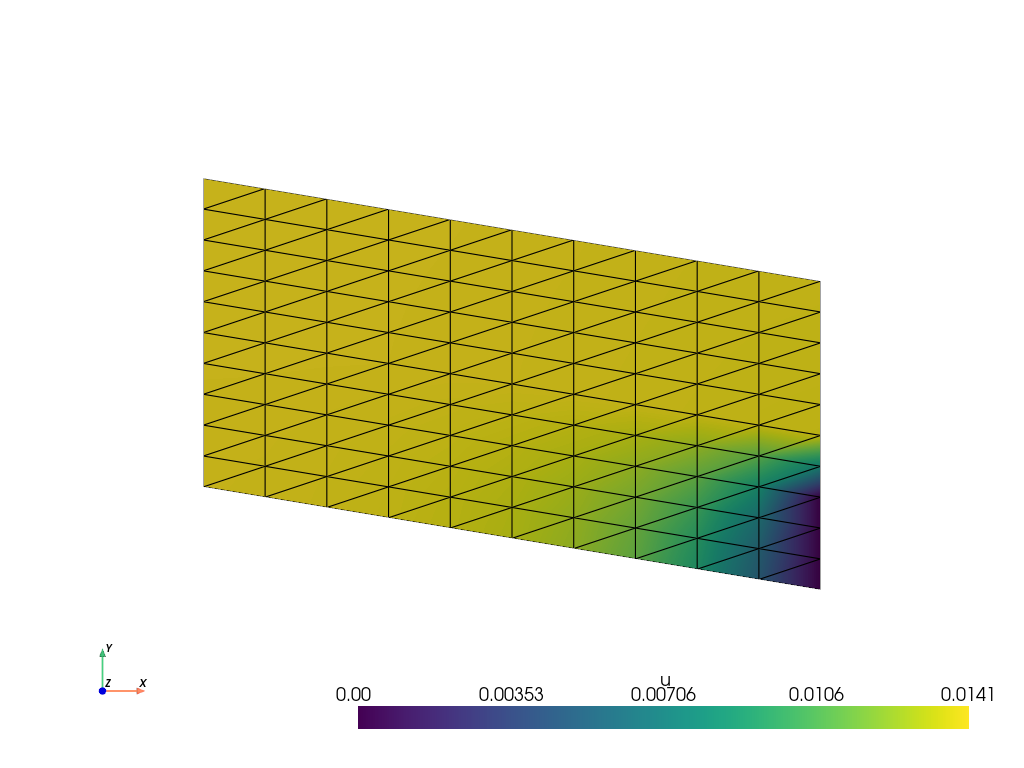

In [11]:
plotScalarFunction(V, u_n)

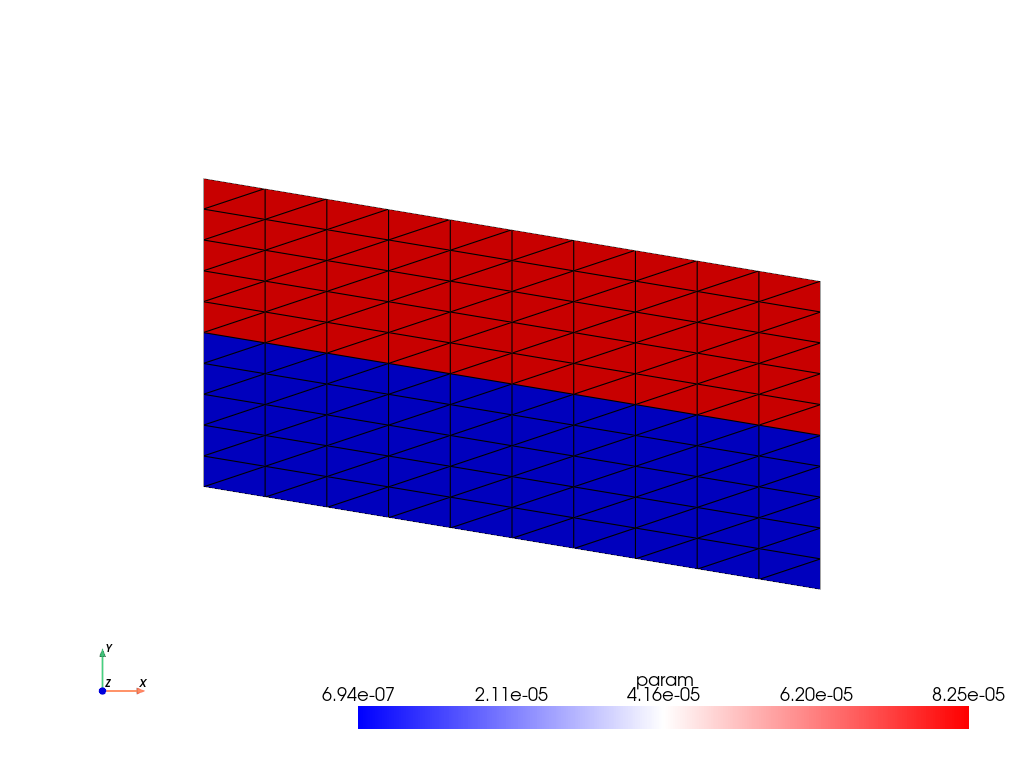

In [34]:
import pyvista
from dolfinx import plot

pyvista.set_jupyter_backend("static")

topology, cell_types, geometry = plot.vtk_mesh(domain, 2)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
grid.cell_data["param"] = Ks.x.array
grid.set_active_scalars("param")
# Create plotter and pyvista grid
p = pyvista.Plotter()
p.add_mesh(grid, show_edges=True, cmap="bwr")
p.view_xy()
p.show_axes()
p.show()

#### Newton:

In [14]:
x = SpatialCoordinate(domain)
uh = Function(V)
u_N = Function(V)
u_N.x.array[:] = -np.ones_like(u_N.x.array)*1e-5 # initial value
x = SpatialCoordinate(domain)

F = C(uh, alpha, n_vg, theta_r, theta_s) / delta_t * (uh - u_N) * v * dx
F += inner(k(uh, alpha, n_vg, Ks) * grad(x[1] + uh), grad(v)) * dx
F += - v*c_in*ds(4)

J = derivative(F, uh)

petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "pc_type": "hypre",
    "pc_hypre_type": "boomeramg",
    "pc_factor_mat_solver_type": "mumps",
    "snes_monitor": "",
    "snes_converged_reason": "",
    "snes_linesearch_monitor": "",
    "ksp_monitor": "",
    "ksp_converged_reason": "",
    "snes_error_if_not_converged": False,
}

delta_u = 1
it = 0

while delta_u > tol and it <= max_iter :
    it += 1
    #print(np.isnan(uh.x.array).any())
    #print(np.isinf(uh.x.array).any())
    #print(np.min(u_N.x.array), np.max(u_N.x.array))
    problem = NonlinearProblem(
        F,
        uh,
        bcs=bcs,
        J=J,
        petsc_options=petsc_options,
        petsc_options_prefix="SNES_",
    )

    uh = problem.solve()
    converged = problem.solver.getConvergedReason()
    num_iter = problem.solver.getIterationNumber()
    assert converged > 0, f"Solver did not converge, got {converged}."
    print(
        f"Solver converged at timestep {it} after {num_iter} iterations with converged reason {converged}."
    )

    delta_u = np.linalg.norm((uh.x.array - u_N.x.array).flatten(), ord = np.inf)
    u_N.x.array[:] = uh.x.array

  Nonlinear SNES_ solve did not converge due to DIVERGED_FNORM_NAN iterations 0


AssertionError: Solver did not converge, got -4.